# Non-differentiable L1 regularization with Sub-Gradient or Proximal Method

## Objective:
##### Implement a small model (e.g. logistic regression) on toy data
##### (or a dataset of your choice), penalizing weights via L1 regularization. We will compare:

- ##### A subgradient descent (explicit management of the L1 norm).
- ##### A proximal update (Prox-SGD).

#### A binary, moderately linearly separable 2D dataset is created.

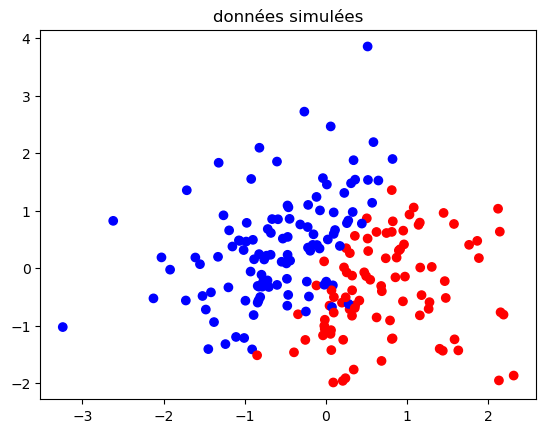

In [2]:
import numpy as np
import matplotlib . pyplot as plt
from IPython.display import display
import pandas as pd 
from PIL import Image

#simulaiton de données binaires

np . random . seed (42)
n_samples = 200
X = np . random . randn ( n_samples , 2)

# Labels basé sur une combinaison linéaire + bruit

true_w = np . array ([2.0 , -1.0])
y_raw = X @ true_w + 0.5 * np . random . randn ( n_samples )
y = ( y_raw > 0) . astype (int) # Label binaire 0 ou 1
plt . scatter ( X [: ,0] , X [: ,1] , c =y , cmap ='bwr')
plt . title ('données simulées')
plt . show ()

### In this exercise, we will use a logistic regression model: 

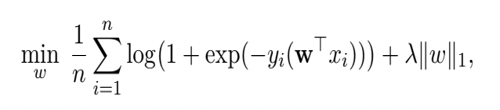

In [ ]:
display((Image.open("logistique.png").convert("RGB")).resize((500, 110)))

## Approach 1 : Sub-Gradient

### The gradient of the logistic part is classical, but the derivative of ∥w∥1 is not defined in wj = 0. We then use the notion of subgradient, where :

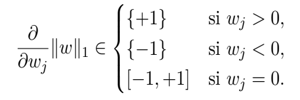

In [4]:
display((Image.open("condition_SG.png").convert("RGB")).resize((300,100)))

In [5]:
def logistic_loss_grad (w , X , y ) :

    # On convertit y de {0 ,1} { -1 , +1} pour simplifier
    y_pm = 2* y - 1 # 0 - > -1 , 1 - >+1
    

    scores = X @ w
    # gradient w.r.t w_j = 1/n * somme (...)
    # ( sigmoide ( -y * x.w) * ( -y * x))
    # On calcule la sigmoid
    sig = 1 / (1 + np . exp ( y_pm * scores ) )
    grad = (1/ len ( y ) ) * ( X . T @ ( sig * ( - y_pm ) ) )
    return grad

In [6]:
def subgradient_step (w , X , y , lr , lambd ) :

    # Gradient de la partie logistique
    grad_log = logistic_loss_grad (w , X , y )

    # Sous - gradient de la partie L1
    subgrad_l1 = np . sign ( w )

    # Correction : sign (0) [ -1 , +1] , on peut le prendre =0 par ex.
    subgrad_l1 [ w == 0] = 0.0
    
    # Mise jour
    w_new = w - lr * ( grad_log + lambd * subgrad_l1 )
    return w_new

In [7]:
def train_subgradient (X , y , lambd =0.01 , lr =0.1 , max_iter =1000) :
    w = np . zeros ( X . shape [1]) # initialisation
    for i in range ( max_iter ) :
        w = subgradient_step (w , X , y , lr , lambd )
    return w

# Entrainement 
w_subgrad = train_subgradient (X , y , lambd =0.01 , lr =0.1 , max_iter =1000)
print (" Poids appris ( descente sous_gradient ) :", w_subgrad )

 Poids appris ( descente sous_gradient ) : [ 3.81874135 -2.0000662 ]


## Approach 2: Prox-SGD

### With the proximal approach, updating takes place in two stages:

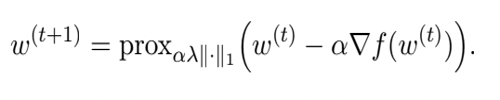

In [8]:
display((Image.open("prox_DG.png").convert("RGB")).resize((500,100)))

### Caution: The prox for the L1 standard is soft-thresholding:

In [9]:
def soft_threshold (z , alpha ) :
    return np . sign ( z ) * np . maximum ( np .abs( z ) - alpha , 0)

def prox_sgd_step (w , X , y , lr , lambd ) :

    # Grad ( partie logistique )
    grad_log = logistic_loss_grad (w , X , y )

    # Mise jour " gradient "
    w_tilde = w - lr * grad_log

    # Application prox -l1 ( soft thresholding )
    w_new = soft_threshold ( w_tilde , lr * lambd )

    return w_new

def train_prox_sgd (X , y , lambd =0.01 , lr =0.1 , max_iter =1000) :

    w = np . zeros ( X . shape [1])
    for i in range ( max_iter ) :
        w = prox_sgd_step (w , X , y , lr , lambd )

    return w


In [10]:
w_prox = train_prox_sgd (X , y , lambd =0.01 , lr =0.1 , max_iter =1000)
print (" Poids appris (prox -SGD) :", w_prox )

 Poids appris (prox -SGD) : [ 3.81870703 -2.00004918]


## Interpretation and Results
 #### - Observe the weights learned for each method. Are they more or less sparse (spars)?
 #### -Add λ to modulate the penalty strength. Observe how certain coefficients become zero (or close to zero).
 #### -Evaluate performance (correct classification rate) and compare.

## 1) Model evaluation

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# On applique les poids idéaux aux features à chaque sample pour chaque model
y_pred_train_train_prox= X_test @ train_prox_sgd(X_train , y_train , lambd =0.01 , lr =0.1 , max_iter =1000).T 
# On applique maintenat une classification binaire à partir d'un seuil, ici le seuil est 0 si on prédit quelque
# chose de negatif alors on attribue 0 sinon 1.
y_pred_train_train_prox=np.where(y_pred_train_train_prox > 0, 1, 0)

y_pred_train_train_subgradient= X_test @ train_subgradient (X_train , y_train , lambd =0.01 , lr =0.1 , max_iter =1000).T
y_pred_train_train_subgradient= np.where(y_pred_train_train_subgradient > 0, 1, 0)


#### Let's use our simple example with two variables to observe how our model succeeds in predicting the correct classes.

Text(0.5, 1.0, 'prox data point')

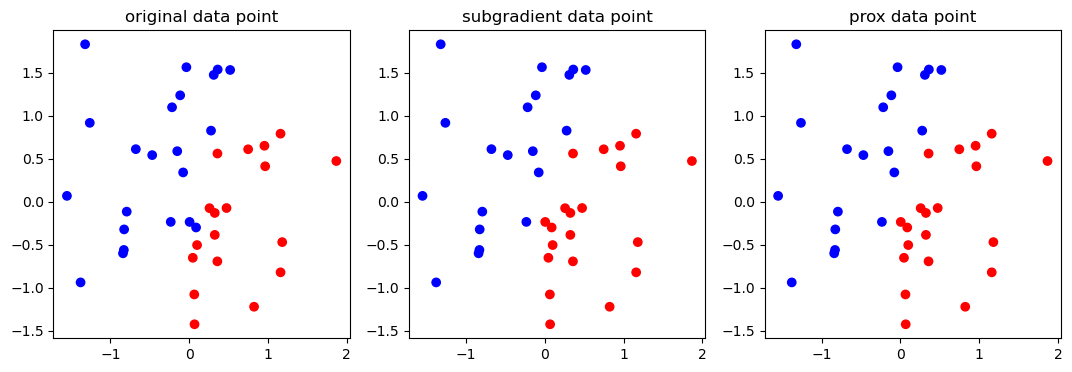

In [ ]:
plt.figure(figsize=((13,4)))
plt.subplot(1,3,1)
plt . scatter ( X_test [: ,0] , X_test [: ,1] , c =y_test , cmap ='bwr') # on affiche les points tests en leur attribuant le label 
                                                                         # correspondant à la classe prédite
plt.title('original data point')
plt.subplot(1,3,2)
plt . scatter ( X_test [: ,0] , X_test [: ,1] , c =y_pred_train_train_subgradient , cmap ='bwr')
plt.title('subgradient data point')
plt.subplot(1,3,3)
plt . scatter ( X_test [: ,0] , X_test [: ,1] , c =y_pred_train_train_prox , cmap ='bwr')
plt.title('prox data point')


#### If we compare the accuracy of our two models, we can see that the problem isn't very complex.

In [19]:
accuracy_score(y_test,y_pred_train_train_prox), accuracy_score(y_test,y_pred_train_train_subgradient)

(0.95, 0.95)

#### We plot the confusion matrices of the results obtained for each of the models.

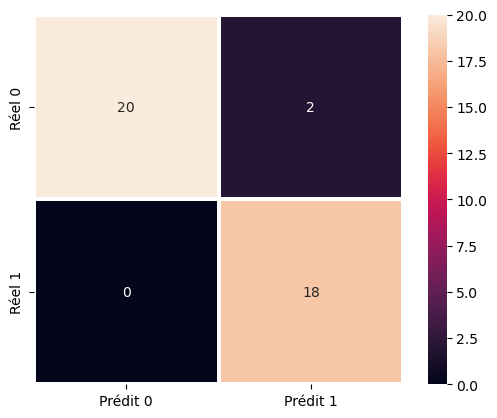

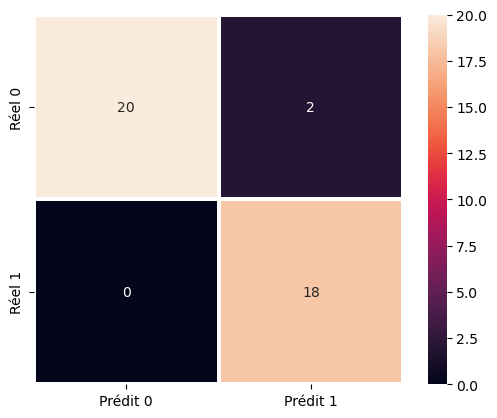

In [20]:
plt.show(sns.heatmap(confusion_matrix(y_test,y_pred_train_train_prox), annot=True, fmt='d', cmap='rocket', cbar=True, linewidths=1.5,
            linecolor='white', square=True,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1']))

plt.show(sns.heatmap(confusion_matrix(y_test,y_pred_train_train_subgradient), annot=True, fmt='d', cmap='rocket', cbar=True, linewidths=1.5,
            linecolor='white', square=True,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
)

## 2) Observing Lambda's impact

#### We'll create a new data set with more features to observe the influence of lambda

In [21]:
n_samples = 2000
X = np . random . randn ( n_samples , 100)

# Labels basé sur une combinaison linéaire + bruit

true_w = np.array([2.0 , -1.0, 1.3, -2.0, 0.4]*20)
y_raw = X @ true_w + 0.5 * np . random . randn ( n_samples )
y = ( y_raw > 0) . astype (int) # Label binaire 0 ou 1

df=pd.DataFrame(X)
df['target']=y
df.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,target
0,0.756989,-0.922165,0.869606,1.355638,0.413435,1.876796,-0.773789,-1.244655,-1.778720,1.496044,...,1.159330,-1.081063,0.615936,0.593101,-0.309546,0.326133,-1.251114,0.924027,-0.184902,1
1,-0.522723,1.049009,-0.704344,-1.408461,-1.556629,0.606010,-1.280429,1.754794,-2.081929,1.696456,...,0.207688,0.271579,-1.276749,-1.081057,1.053153,-0.039555,0.681501,0.028318,0.029756,1
2,0.938284,-0.516045,0.096121,-0.462275,-0.434496,-0.309172,0.222134,-0.478749,1.255756,-0.894607,...,0.507274,1.066675,1.169296,1.382159,0.648710,-0.167118,0.146714,1.206509,-0.816936,1
3,0.368673,-0.393339,0.028745,1.278452,0.191099,0.046437,-1.359856,0.746254,0.645484,2.163255,...,-2.041735,-0.247177,-0.681984,-1.001620,-0.281100,1.797687,0.640843,-0.571179,0.572583,0
4,1.399355,0.924634,0.059630,-0.646937,0.698223,0.393485,0.895193,0.635172,1.049553,-0.535235,...,-0.037222,0.727630,0.051946,0.732640,-0.080717,0.078635,-1.998201,0.916328,0.346488,1


In [22]:
X_train_, X_test_, y_train_, y_test_ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Adjust λ to modulate the penalty force, and observe how the weights are transformed into 0

In [23]:
num_zero_weights = [] # liste du nb de poids à 0 au fur et a mesure que l'on augmente lambda 
accuracy_list = [] # évolution de l'accuracy au cours des tests 
lambda_test=np.arange(0.01, 0.5, 0.01) # array de lambda a tester 

for lam in lambda_test :
    w_l1=train_prox_sgd(X_train_ , y_train_ , lambd =lam , lr =0.1 , max_iter =1000)

    zeros = np.sum(np.abs(w_l1) < 1e-6)  # seuil de tolérance
    num_zero_weights.append(zeros)
    
    #Prédictions et accuracy
    y_scores_test = X_test_ @ w_l1
    y_pred_test = (y_scores_test > 0).astype(int)
    acc = accuracy_score(y_test_, y_pred_test)

    accuracy_list.append(acc)


num_zero_weights = np.array(num_zero_weights)
accuracy_list = np.array(accuracy_list)

### Sparsity (nb weights ≈ 0) vs log(λ)

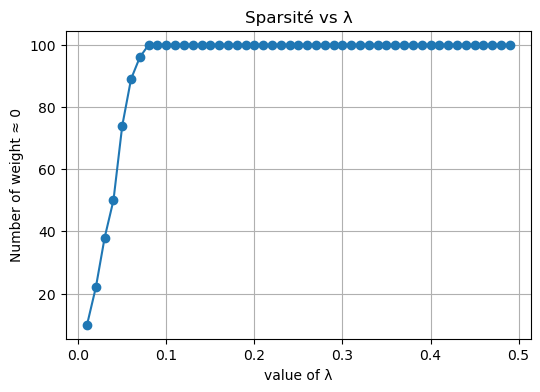

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(0.01, 0.5, 0.01), num_zero_weights, marker='o')
plt.xlabel('value of λ')
plt.ylabel('Number of weight ≈ 0')
plt.title('Sparsité vs λ')
plt.grid(True)
plt.show()

#### We can see that as lambda increases, the matrix becomes sparse.

### Accuracy vs log(λ)

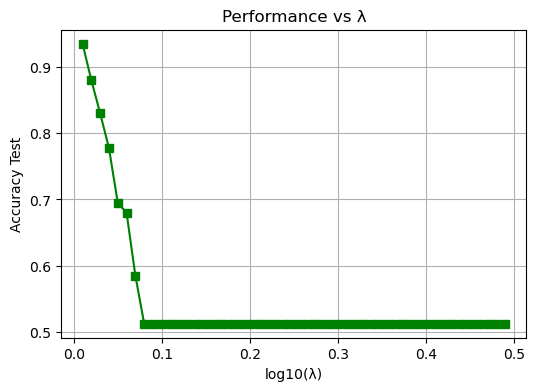

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(0.01, 0.5, 0.01), accuracy_list, marker='s', color='green')
plt.xlabel('log10(λ)')
plt.ylabel('Accuracy Test')
plt.title('Performance vs λ')
plt.grid(True)
plt.show()

# Conclusion 

#### In this tutorial, we studied logistic regression with L1 regularization, exploring different optimization methods for solving the problem: subgradient descent and the proximal (prox) approach. The aim was to analyze the impact of regularization on learned weights and model performance, while comparing the quality of solutions obtained by these two algorithms.

#### Our results show that, whatever the optimization method used, increasing the regularization parameter λ leads to a significant increase in sparsity: more and more features have zero coefficients, in line with the properties of L1 regularization, which favors automatic variable selection.

#### In parallel, we observed a drop in accuracy on the test set as λ increases, reflecting the trade-off between model simplification and generalization capacity. Too high a λ penalizes the weights, which is detrimental to performance.

Alexandro Bizeul